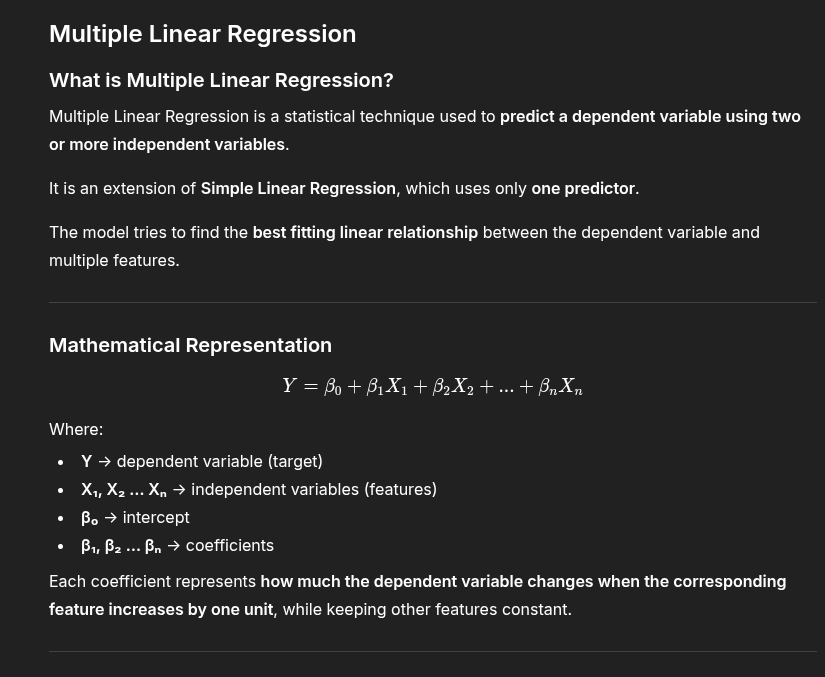

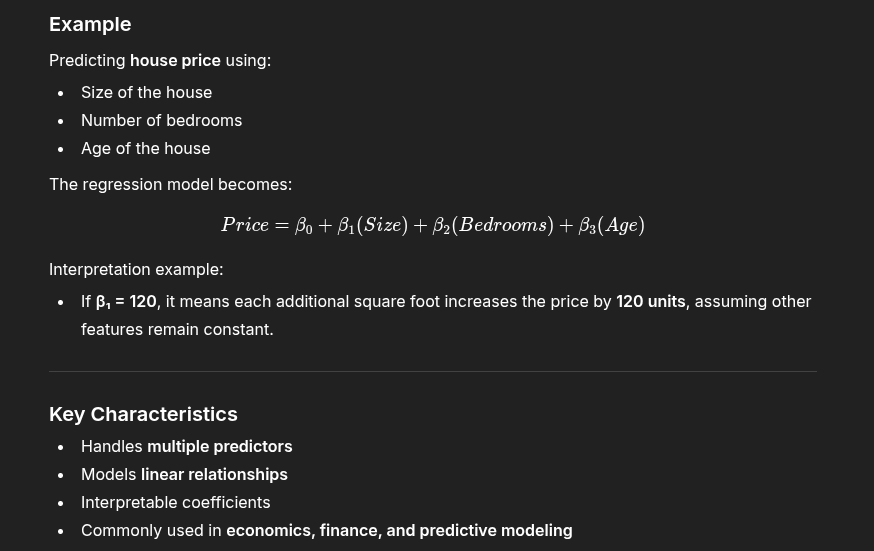

In [1]:
import sys
print(sys.executable)

/home/tanisha/Documents/MLTP_MCA/MLTP/venv/bin/python


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("Data/advertising.csv")

print(df.head())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


In [4]:
X = df.drop(columns = 'Sales', axis=1)
y = df['Sales']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [6]:
mlr_model = LinearRegression()

mlr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
y_train_pred = mlr_model.predict(X_train)
y_test_pred = mlr_model.predict(X_test)

In [8]:
print("Intercept:", mlr_model.intercept_)
print("Coefficients:", mlr_model.coef_)

Intercept: 4.714126402214127
Coefficients: [0.05450927 0.10094536 0.00433665]


Regression Evaluation Metrics Explanation
1. Mean Absolute Error (MAE)

𝑀𝐴𝐸 = 1/𝑛 ∑∣𝑦−𝑦∣

Meaning:

Average absolute difference between actual and predicted values. 
Lower value → better model.

2. Mean Squared Error (MSE)

𝑀𝑆𝐸 = 1/𝑛∑(𝑦−𝑦)^2

Characteristics:

a. Squares the errors
b. Penalizes large errors
c. Lower value → better model.

3. Root Mean Squared Error (RMSE)

𝑅𝑀𝑆𝐸 = (𝑀𝑆𝐸)^(1/2)

Advantages:

a. Same unit as target variable
b. Easy to interpret
c. Lower value → better model.

4. R² Score (Coefficient of Determination)

𝑅2 = 1−(𝑆𝑆𝑟𝑒𝑠/𝑆𝑡𝑜𝑡)

Range:

a. 1 → perfect model
b. 0 → no predictive power
c. Negative → very poor model
d. Higher value → better model.

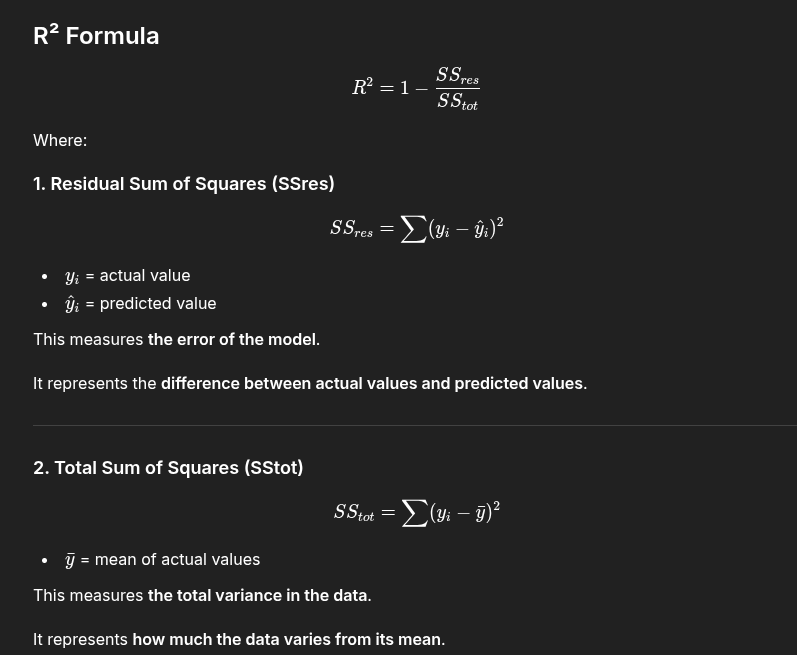

In [9]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

print("Training Metrics")
print("MAE:", mae_train)
print("MSE:", mse_train)
print("RMSE:", rmse_train)
print("R2:", r2_train)

Training Metrics
MAE: 1.2344160869575869
MSE: 2.676142653782669
RMSE: 1.635892005537856
R2: 0.9001416005862131


In [10]:
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print("\nTesting Metrics")
print("MAE:", mae_test)
print("MSE:", mse_test)
print("RMSE:", rmse_test)
print("R2:", r2_test)


Testing Metrics
MAE: 1.2748262109549338
MSE: 2.9077569102710896
RMSE: 1.7052146229349223
R2: 0.9059011844150826


## Polynomial Regression

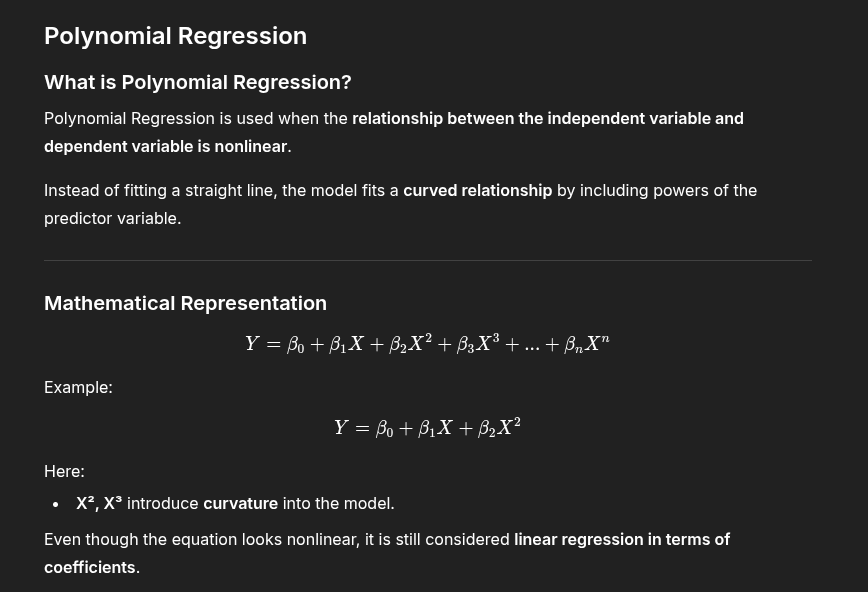

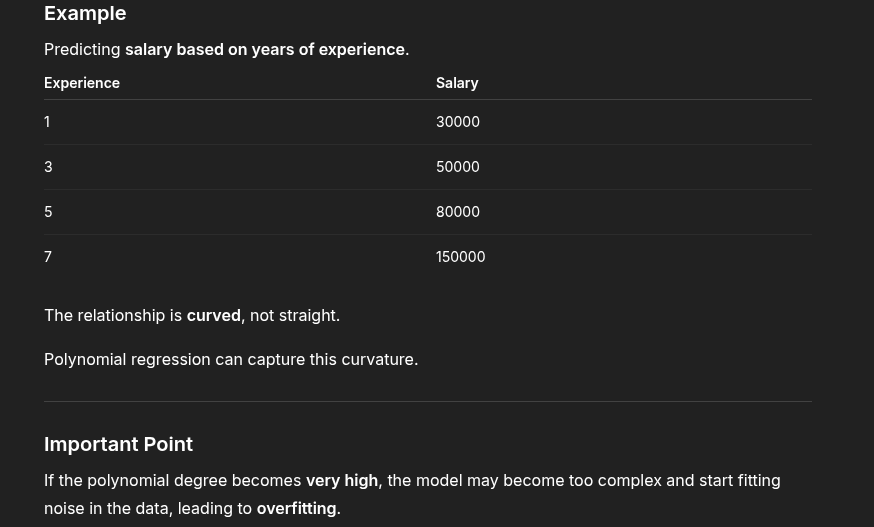

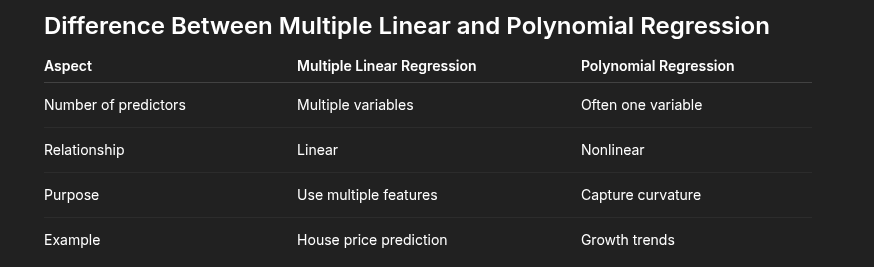

In [11]:
poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

In [12]:
X_train_poly, X_test_poly, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

In [13]:
poly_model = LinearRegression()

poly_model.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_train_poly_pred = poly_model.predict(X_train_poly)
y_test_poly_pred = poly_model.predict(X_test_poly)

In [15]:
mae_train_poly = mean_absolute_error(y_train, y_train_poly_pred)
mse_train_poly = mean_squared_error(y_train, y_train_poly_pred)
rmse_train_poly = np.sqrt(mse_train_poly)
r2_train_poly = r2_score(y_train, y_train_poly_pred)

print("Polynomial Training Metrics")
print("MAE:", mae_train_poly)
print("MSE:", mse_train_poly)
print("RMSE:", rmse_train_poly)
print("R2:", r2_train_poly)

Polynomial Training Metrics
MAE: 1.0565622765314322
MSE: 1.9077576664191824
RMSE: 1.3812160100502682
R2: 0.9288133512730626


In [16]:
mae_test_poly = mean_absolute_error(y_test, y_test_poly_pred)
mse_test_poly = mean_squared_error(y_test, y_test_poly_pred)
rmse_test_poly = np.sqrt(mse_test_poly)
r2_test_poly = r2_score(y_test, y_test_poly_pred)

print("\nPolynomial Testing Metrics")
print("MAE:", mae_test_poly)
print("MSE:", mse_test_poly)
print("RMSE:", rmse_test_poly)
print("R2:", r2_test_poly)


Polynomial Testing Metrics
MAE: 0.9033713382792442
MSE: 1.44254263690159
RMSE: 1.2010589647896517
R2: 0.9533174341074723


In [17]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


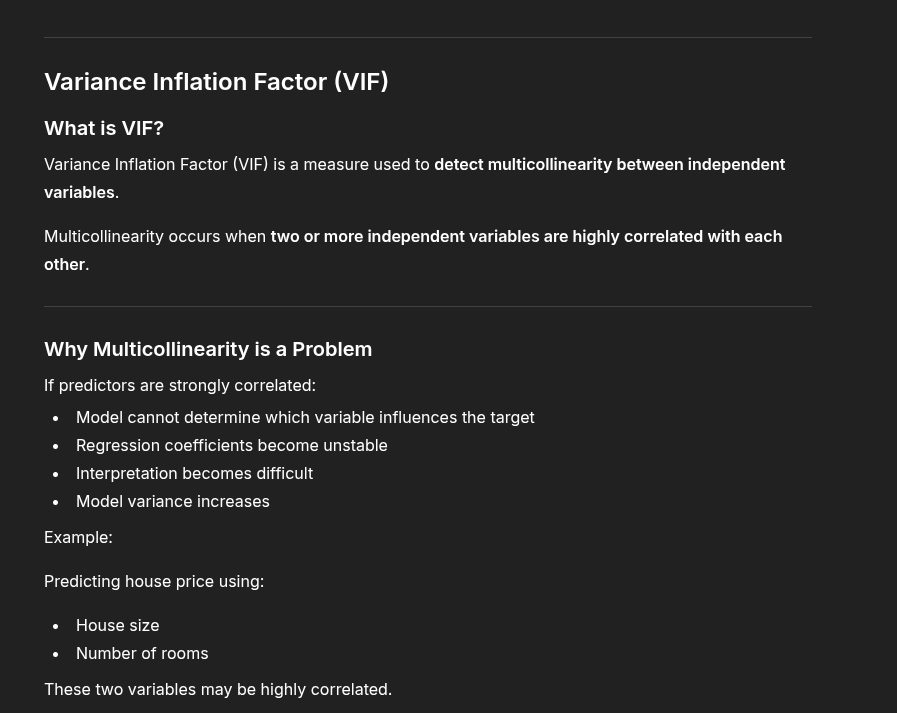

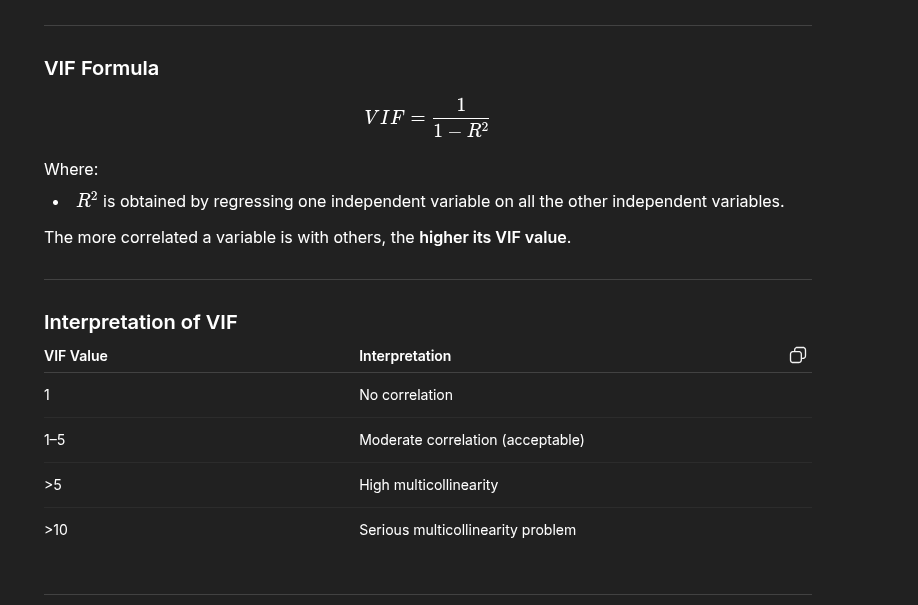

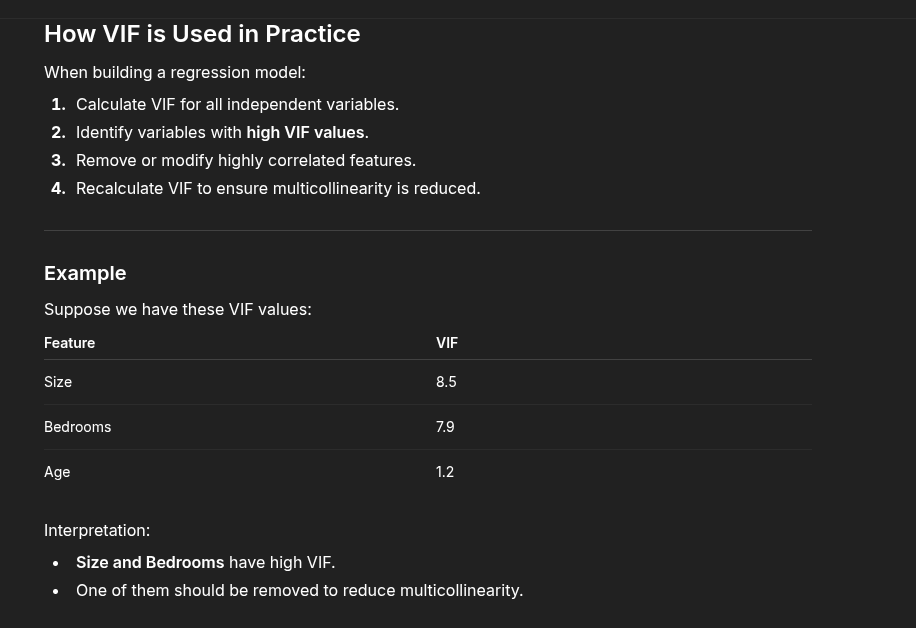

In [18]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [19]:
vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

     Feature       VIF
0         TV  2.486772
1      Radio  3.285462
2  Newspaper  3.055245


In [20]:
X["dummy"] = 2*X["TV"]
vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

     Feature       VIF
0         TV       inf
1      Radio  3.285462
2  Newspaper  3.055245
3      dummy       inf


/home/tanisha/Documents/MLTP_MCA/MLTP/venv/lib/python3.10/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)
